In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
#data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.isna().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [8]:
# Convert date columns
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True, errors='coerce')

In [10]:
# Handle missing Postal Code
df['Postal_Code'] = df['Postal_Code'].fillna(0)

In [12]:
df.isna().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64

In [15]:
# feature engineering
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year

In [16]:
total_sales = df['Sales'].sum()
avg_sales = df['Sales'].mean()

print("Total Sales:", total_sales)
print("Average Sales:", avg_sales)

Total Sales: 2261536.7827000003
Average Sales: 230.7690594591837


In [17]:
## Sales By Region

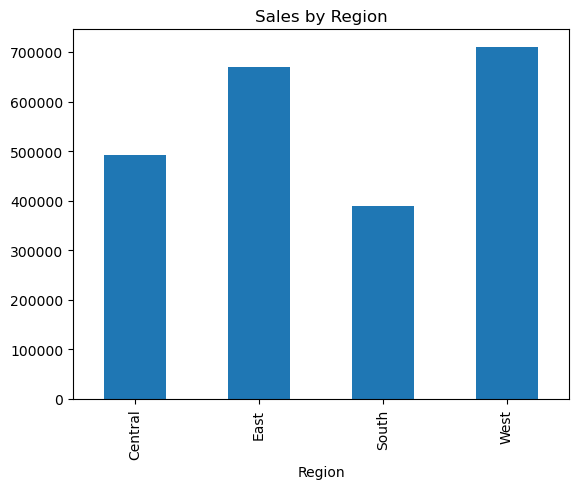

In [18]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

In [19]:
## Sales by category

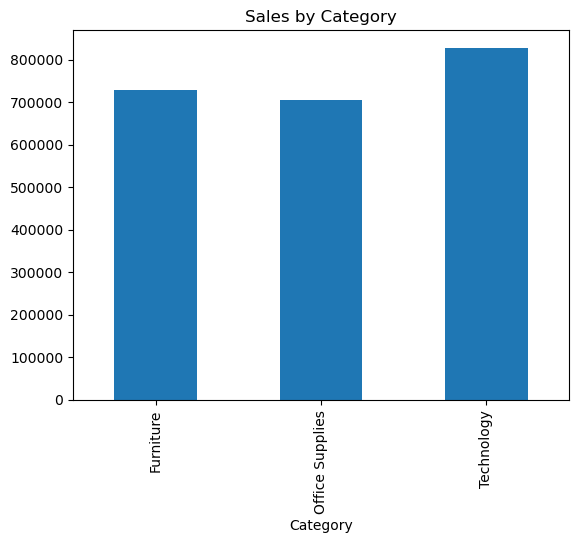

In [20]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

In [21]:
## Monthly sales trend

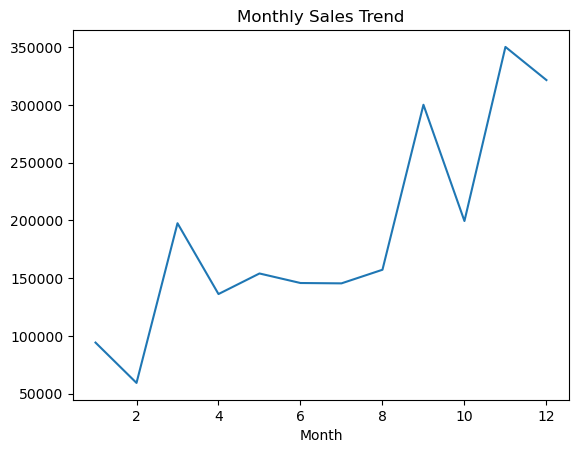

In [22]:
df.groupby('Month')['Sales'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

In [23]:
# top 10 products

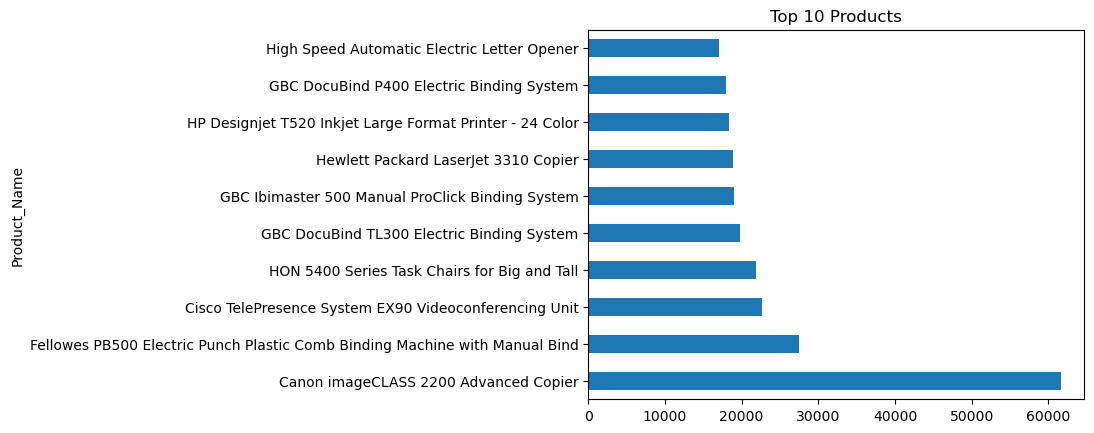

In [24]:
df.groupby('Product_Name')['Sales'].sum().nlargest(10).plot(kind='barh')
plt.title("Top 10 Products")
plt.show()

In [25]:
# sales by segment

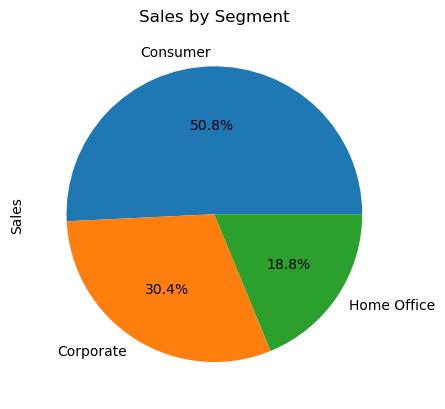

In [26]:
df.groupby('Segment')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Segment")
plt.show()

## Key Insights
- West and East regions generate the highest sales, while South lags behind
- Technology category performs best among all categories
- Sales show seasonal peaks (Sep–Dec), especially in November
- A few products drive most revenue (top products dominate sales)
- Consumer segment (~50%) is the largest contributor

## Recommendations
- Focus marketing on high-performing regions (West, East)
- Improve South region with targeted campaigns
- Expand and promote Technology products
- Run offers before peak months (Sep–Nov)
- Promote top-selling products aggressively
- Target Consumer segment with personalized strategies